# FSCI 396: Structural Equation Modelling

------------------
Welcome to today's tutorial! 
Today we'll use Python in Jupyter Notebook to perform some common statistical analyses.
We will cover: Structural Equation Modelling

The goal is to see how we can analyze data with Python, just like we discussed in lectures.


### Steps to Debugging 

I am here to help you! But before you contact me, make sure you have tried the following:
1. Ensure that all brackets and parentheses are paired.
2. Ensure that your code does not have any typos (eg. when calling your data file).
3. Ensure you did not add additional spaces (eg. when calling your data file).
4. You have restarted your kernel and reun your code. 
5. You have tried to understand the error message. 

If you have done all of these things, I am very happy to help! 

In [1]:
# Import Modules
# ---------------

# Modules in Python are like library books. 
# Each book contains a set of instructions or “recipes” for doing specific tasks.
# - pandas: for handling and analyzing tables of data
# - semopy: used for structural equation modelling 

import pandas as pd
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


# Ignore Warnings for simplicity
import warnings
warnings.filterwarnings('ignore')

# Quick check to see if modules loaded correctly
print("Modules loaded successfully!")


Modules loaded successfully!


In [2]:
# Load datafile/dataframe (df) from CSV
# --------------------------------------

# Here we load our data. Make sure the CSV file is in the same folder as this notebook.

# If your file is excel, use these two lines:
filename = 'Anon_Compiled_Qual_2024-2025_Grades.xlsx'    # Name of your file
df = pd.read_excel(filename)         # Read the CSV into a DataFrame

# If your data is .csv, use these two lines: 
# filename = 'SampleData.csv'    # Name of your file
# df = pd.read_csv(filename)         # Read the CSV into a DataFrame

# Checkpoint to ensure the file has been loaded 
print(filename, 'has been loaded')


Anon_Compiled_Qual_2024-2025_Grades.xlsx has been loaded


In [47]:
# Defining function to calculate partial correlations and significance values 

def prepare_covariates(df, controls):
    numeric_covs = [c for c in controls if pd.api.types.is_numeric_dtype(df[c])]
    cat_covs = [c for c in controls if not pd.api.types.is_numeric_dtype(df[c])]
    
    if cat_covs:
        cat_covs_dummies = pd.get_dummies(df[cat_covs], drop_first=False)  # keep all categories
    else:
        cat_covs_dummies = pd.DataFrame(index=df.index)
    
    covariates = pd.concat([df[numeric_covs], cat_covs_dummies], axis=1)
    return covariates

def partialCorr(variables, covariates):

    # 3. Combine numeric columns + covariates
    df_numeric = pd.concat([df, covariates], axis=1)

    # 4. Create empty DataFrames for r values and annotations
    pcorr_matrix = pd.DataFrame(index=vars_ordered, columns=vars_ordered, dtype=float)
    annot_matrix = pd.DataFrame(index=vars_ordered, columns=vars_ordered, dtype=str)

    # 5. Compute partial correlations and significance
    for var1 in vars_ordered:
        for var2 in vars_ordered:
            if var1 == var2:
                pcorr_matrix.loc[var1, var2] = 1.0
                annot_matrix.loc[var1, var2] = '1.00'
            else:
                result = pg.partial_corr(data=df_numeric, x=var1, y=var2, covar=covariates.columns.tolist())
                r = result['r'].values[0]
                p = result['p-val'].values[0]

                # Assign significance stars
                if p < 0.01:
                    star = '**'
                elif p < 0.05:
                    star = '*'
                else:
                    star = ''

                pcorr_matrix.loc[var1, var2] = r
                annot_matrix.loc[var1, var2] = f'{r:.2f}{star}'

    # 6. Plot the heatmap
    plt.figure(figsize=(10,8))
    sns.heatmap(pcorr_matrix.astype(float), annot=annot_matrix, fmt='', cmap='coolwarm', center=0, square=True)
    plt.title('Partial Correlation Heatmap')
    plt.savefig('PartialCorrelationsHeatMap')
    plt.show()

    # 7. Print explanation for significance symbols
    print("*  = p < 0.05")
    print("** = p < 0.01")
    return 

In [4]:
# df['Course'].unique()

# only do the courses with grades
(['BIOL1XX',  'MIMM2XX','ANAT3XX','PSYCH2XX', 'BIOC3XX',
  
t  'PHYS1XX',  'MATH2XX', 'ATOC1XX', 'COMP2AX', 'COMP2BX'],

# Life-> Anatomy, Biology, Microbiology, Psychology
# Physical-> Physical, Mathematics, Atmospheric, Computer Science

array(['BIOL1XX', 'PHYS1XX', 'BIOC3XX', 'MIMM2XX', 'MATH2XX', 'PSYCH2XX',
       'ATOC1XX', 'ANAT3XX', 'COMP2AX', 'COMP2BX'], dtype=object)

In [20]:
import sqlite3
db = sqlite3.connect('OSE.db')

df.to_sql('FSCI',db)

939

In [43]:
query= """
SELECT *
FROM FSCI
WHERE Course IN ('PHYS1XX', 'MATH2XX','ATOC1XX','COMP2AX','COMP2BX') 
    AND Grade IS NOT NULL
"""

phys = pd.read_sql(query, db)


query= """
SELECT *
FROM FSCI
WHERE Course IN ('BIOL1XX', 'MIMM2XX','ANAT3XX','PSYCH2XX','BIOC3XX') 
    AND Grade IS NOT NULL
"""

life = pd.read_sql(query, db)

In [12]:
# Remove all responses without grades to avoid errors/complications 
df = df[df['Grade'].notna()]
df.columns

Index(['Unnamed: 0', 'CW1', 'CW2', 'CW3', 'EM1', 'EM2', 'EM3', 'EM4', 'DS1',
       'DS2', 'DS3', 'DS4', 'DS5', 'AnxTest1', 'AnxTest2', 'AnxTest3',
       'AnxWrit1', 'AnxWrit2', 'AnxWrit3', 'AnxPres1', 'AnxPres2', 'AnxPres3',
       'AnxGrp1', 'AnxGrp2', 'AnxGrp3', 'R1', 'R2', 'R3', 'R4', 'E1', 'E2',
       'E3', 'E4', 'E5', 'E6', 'SE1', 'SE2', 'SE3', 'SE4', 'SE5', 'SE6', 'SE7',
       'SE8', 'PredictedGrade', 'Degree', 'Citizenship', 'YearOfStudy',
       'Field', 'McGillLearningStratParticipation', 'Gender', 'YoB', 'Credits',
       'Disability', 'Minority', 'FirstGen', 'Grade', 'CognitiveWorry',
       'Emotionality', 'Distraction', 'Rehearsal', 'Elaboration',
       'State_Anxiety', 'SelfEfficacy', 'Anxiety_test', 'Anxiety_writing',
       'Anxiety_speaking', 'Anxiety_group', 'semester', 'Course', 'Qual2_Anon',
       'Qual1_Anon'],
      dtype='object')

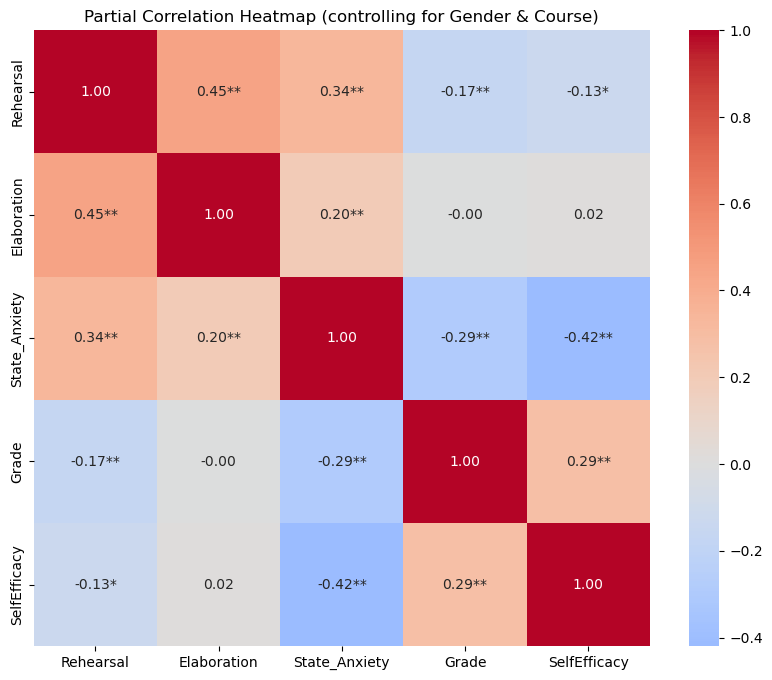

In [51]:
# import pandas as pd
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = phys

# 1. Define the variables in the desired order
vars_ordered = ['Rehearsal', 'Elaboration', 'State_Anxiety', 'Grade', 'SelfEfficacy']

# 2. Create dummy covariates for Gender and Course
covariates = pd.get_dummies(df[['Gender','Course']], drop_first=True)

# 3. Combine numeric columns + covariates
df_numeric = pd.concat([df, covariates], axis=1)

# 4. Create empty DataFrames for r values and annotations
pcorr_matrix = pd.DataFrame(index=vars_ordered, columns=vars_ordered, dtype=float)
annot_matrix = pd.DataFrame(index=vars_ordered, columns=vars_ordered, dtype=str)

# 5. Compute partial correlations and significance
for var1 in vars_ordered:
    for var2 in vars_ordered:
        if var1 == var2:
            pcorr_matrix.loc[var1, var2] = 1.0
            annot_matrix.loc[var1, var2] = '1.00'
        else:
            result = pg.partial_corr(data=df_numeric, x=var1, y=var2, covar=covariates.columns.tolist())
            r = result['r'].values[0]
            p = result['p-val'].values[0]

            # Assign significance stars
            if p < 0.01:
                star = '**'
            elif p < 0.05:
                star = '*'
            else:
                star = ''

            pcorr_matrix.loc[var1, var2] = r
            annot_matrix.loc[var1, var2] = f'{r:.2f}{star}'

# 6. Plot the heatmap
plt.figure(figsize=(10,8))
sns.heatmap(pcorr_matrix.astype(float), annot=annot_matrix, fmt='', cmap='coolwarm', center=0, square=True)
plt.title('Partial Correlation Heatmap (controlling for Gender & Course)')
plt.savefig('PartialCorr_Life')
plt.show()


In [48]:
controls = ['Gender','Course']  # mix of numeric and categorical
covariates = prepare_covariates(df, controls)

partialCorr(controls, covariates)


NameError: name 'vars_ordered' is not defined